In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

from pathlib import Path
from PIL import Image
import librosa

In [6]:
# load project modules
from song_recommender.paths import *
from song_recommender.data.indexer import *

# Spectrogram EDA:

In this notebook, we examine the data contained in the spectrogram pngs generated from our audio dataset. First, we add audio (original track and stems), spectrogram png, and spectrogram npy path lists to the dataframe. Each list is ordered: original track, bass stem, drum stem, other stem, vocals stem.

In [ ]:
df = pd.read_pickle(f'{DATA_DIR}/metadata.pkl')

indexer = TrackIndexer(df)
df = indexer.add_paths_to_df()
df.sample(5)

,track_id,name,artist,spotify_preview_url,spotify_id,tags,genre,year,duration_ms,danceability,...,valence,tempo,time_signature,crude_genre,duration_min,clip_duration,decade,audio_paths,spec_png_paths,spec_raw_paths
9378,TRHMFWC12903CDF098,After World Obliteration,Terrorizer,https://p.scdn.co/mp3-preview/83f0a49682becad2...,1B3EH5RE7LhigcjdBhlY5F,"death_metal, grindcore",Metal,1989,209573,0.230,...,0.0365,111.790,4,metal,3.492883,10.0,1980,[/Users/mitch/Library/CloudStorage/GoogleDrive...,[/Users/mitch/Library/CloudStorage/GoogleDrive...,[/Users/mitch/Library/CloudStorage/GoogleDrive...
3125,TRFHHMJ128F9350D45,Audience of One,Rise Against,https://p.scdn.co/mp3-preview/8488c0e8203ebd94...,0qCRySiUbEHH12C9KM79bi,"rock, punk, hardcore, punk_rock, 00s",NaN,2012,245480,0.396,...,0.7060,161.988,4,metal,4.091333,10.0,2010,[/Users/mitch/Library/CloudStorage/GoogleDrive...,[/Users/mitch/Library/CloudStorage/GoogleDrive...,[/Users/mitch/Library/CloudStorage/GoogleDrive...
3411,TRAASQC128F93480F0,Amber Changing,Rise Against,https://p.scdn.co/mp3-preview/a9c2063705b2a96f...,0i1tI3mNXGAq9M0ZwbZ9ls,"punk, hardcore, punk_rock",NaN,2013,176146,0.315,...,0.5180,105.692,3,metal,2.935767,10.0,2010,[/Users/mitch/Library/CloudStorage/GoogleDrive...,[/Users/mitch/Library/CloudStorage/GoogleDrive...,[/Users/mitch/Library/CloudStorage/GoogleDrive...
7078,TRUGIST128F427BBE8,Doomed Now,"Does It Offend You, Yeah?",https://p.scdn.co/mp3-preview/26770dff02e9afff...,0zjuldQzOzfUinoNI19c7Y,"electronic, dance, electro",NaN,2008,221133,0.512,...,0.7150,150.013,4,electronic,3.685550,10.0,2000,[/Users/mitch/Library/CloudStorage/GoogleDrive...,[/Users/mitch/Library/CloudStorage/GoogleDrive...,[/Users/mitch/Library/CloudStorage/GoogleDrive...
4226,TRIRSOH128F9305540,Rally,Phoenix,https://p.scdn.co/mp3-preview/f8a44804e3c85e5c...,0YxwQNhgsLBAcE9NICQoT3,"indie, indie_rock, indie_pop, french, pop_rock",Reggae,2006,197106,0.665,...,0.9220,147.894,4,rock,3.285100,10.0,2000,[/Users/mitch/Library/CloudStorage/GoogleDrive...,[/Users/mitch/Library/CloudStorage/GoogleDrive...,[/Users/mitch/Library/CloudStorage/GoogleDrive...


We extract the png paths to their own columns.

In [9]:
labels = ['full'] + indexer.stem_list

for index, label in enumerate(labels):
    df[f'{label}_png_path'] = df['spec_png_paths'].apply(lambda x: x[index])

## Feature Engineering

We add a energy features related to the png data.

### 1. Energy

We compute the pixel energy for each generated image.

In [14]:
def energy(path):
    img = np.array(Image.open(path).convert("L"))
    return img.sum()

for label in labels:
    df[f'{label}_energy'] = df[f'{label}_png_path'].apply(energy)

In [15]:
energy_cols = ["bass_energy","drums_energy","vocals_energy","other_energy"]

df["stem_sum"] = df[energy_cols].sum(axis=1)

for stem in ["bass","drums","vocals","other"]:
    df[f"{stem}_ratio"] = df[f"{stem}_energy"] / df["stem_sum"]

In [16]:
df[["bass_ratio","drums_ratio","vocals_ratio","other_ratio"]].describe()

,bass_ratio,drums_ratio,vocals_ratio,other_ratio
count,11239.000000,11239.000000,1.123900e+04,11239.000000
mean,0.108832,0.254884,2.241181e-01,0.412166
std,0.052602,0.118664,1.561037e-01,0.155329
min,0.000172,0.000369,5.150421e-07,0.024175
25%,0.080589,0.202527,8.104779e-02,0.320342
50%,0.108858,0.271581,2.493692e-01,0.385926
75%,0.137536,0.327498,3.252811e-01,0.478594
max,0.531467,0.848855,9.750112e-01,0.993177


In [17]:
df["dominant_stem"] = df[energy_cols].idxmax(axis=1)
df["dominant_stem"].value_counts(normalize=True)

dominant_stem
other_energy     0.679954
vocals_energy    0.186582
drums_energy     0.132574
bass_energy      0.000890
Name: proportion, dtype: float64

In [ ]:
df.groupby("crude_genre")[[
    "bass_ratio","drums_ratio","vocals_ratio","other_ratio"
]].mean().sort_values("vocals_ratio", ascending=False)

,bass_ratio,drums_ratio,vocals_ratio,other_ratio
crude_genre,,,,
hip_hop,0.083912,0.290268,0.383577,0.242243
folk,0.073382,0.135103,0.327780,0.463735
country,0.078959,0.168215,0.325568,0.427259
reggae/ska,0.093376,0.265506,0.295069,0.346049
pop,0.100244,0.244333,0.282352,0.373072
rnb/soul,0.100006,0.274367,0.281330,0.344296
blues,0.043166,0.177436,0.280772,0.498625
world,0.086487,0.234357,0.263426,0.415730
new_age,0.082674,0.131841,0.234785,0.550700


In [18]:
import matplotlib.pyplot as plt

def plot_top_genres_by_ratio(df, ratio_col, title, min_count=50, top_n=12):
    # Filter small genres
    genre_counts = df["crude_genre"].value_counts()
    valid_genres = genre_counts[genre_counts >= min_count].index

    data = (
        df[df["crude_genre"].isin(valid_genres)]
        .groupby("crude_genre")[ratio_col]
        .mean()
        .sort_values(ascending=False)
        .head(top_n)
    )

    plt.figure(figsize=(10,6))
    plt.barh(data.index[::-1], data.values[::-1])
    plt.xlabel(f"Mean {ratio_col.replace('_',' ').title()}")
    plt.title(title)

    for i, v in enumerate(data.values[::-1]):
        plt.text(v, i, f"{v:.3f}", va='center')

    plt.tight_layout()
    plt.show()

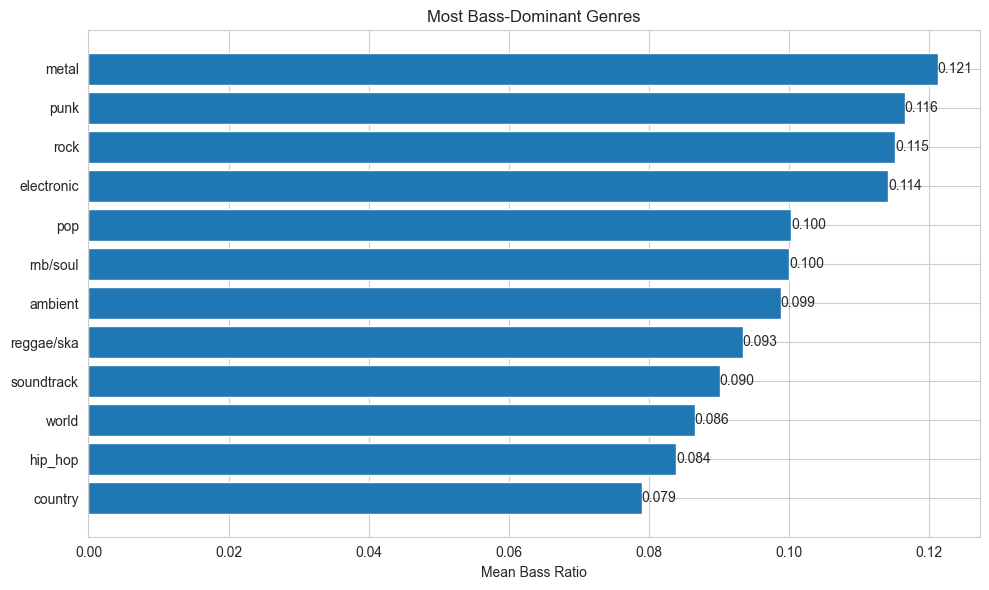

In [19]:
plot_top_genres_by_ratio(
    df,
    "bass_ratio",
    "Most Bass-Dominant Genres"
) 

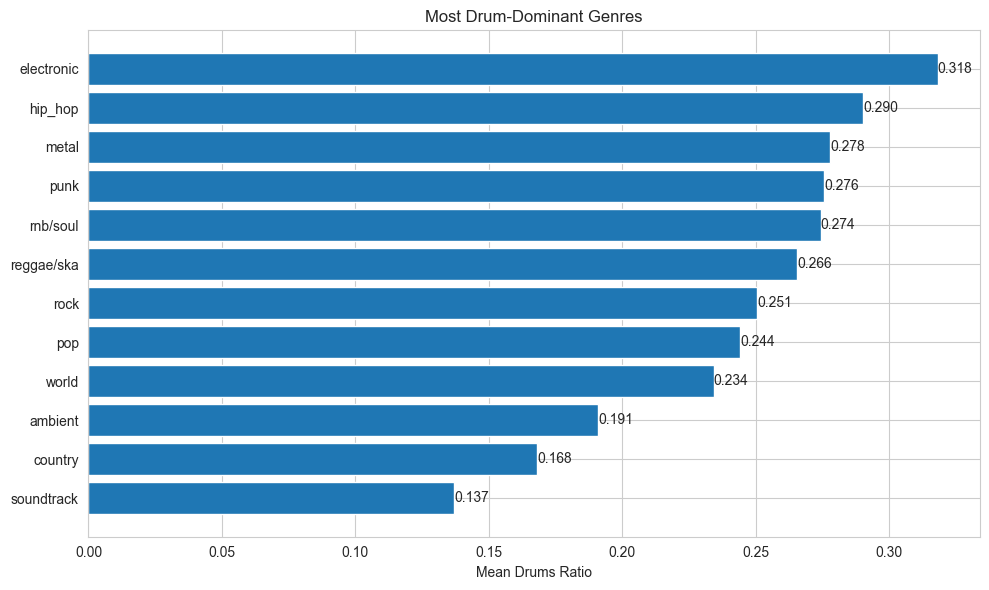

In [20]:
plot_top_genres_by_ratio(
    df,
    "drums_ratio",
    "Most Drum-Dominant Genres"
)

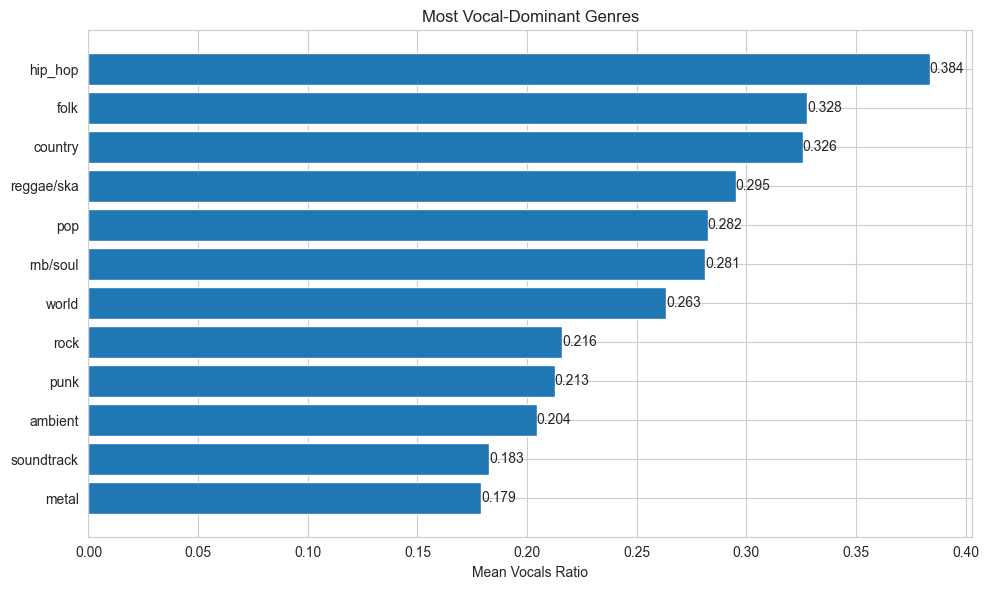

In [21]:
plot_top_genres_by_ratio(
    df,
    "vocals_ratio",
    "Most Vocal-Dominant Genres"
)

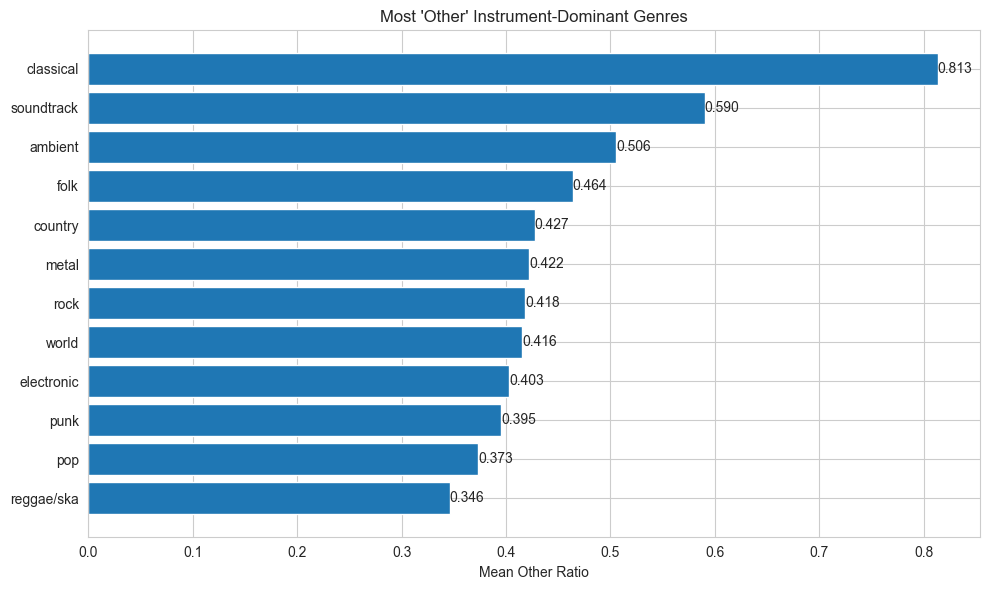

In [22]:
plot_top_genres_by_ratio(
    df,
    "other_ratio",
    "Most 'Other' Instrument-Dominant Genres"
)